  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 891.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 142.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 38.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.21.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.34.1 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.21.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
google-cloud-spanner 3.64.0 requires

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/4 [00:00<?, ? splits/s]

...

Generating testA examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cycle_gan/horse2zebra/incomplete.54FGYZ_3.0.0/cycle_gan-testA.tfrecord*...…

Generating testB examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cycle_gan/horse2zebra/incomplete.54FGYZ_3.0.0/cycle_gan-testB.tfrecord*...…

Dataset cycle_gan downloaded and prepared to /root/tensorflow_datasets/cycle_gan/horse2zebra/3.0.0. Subsequent calls will reuse this data.
Sample horse -> zebra before training


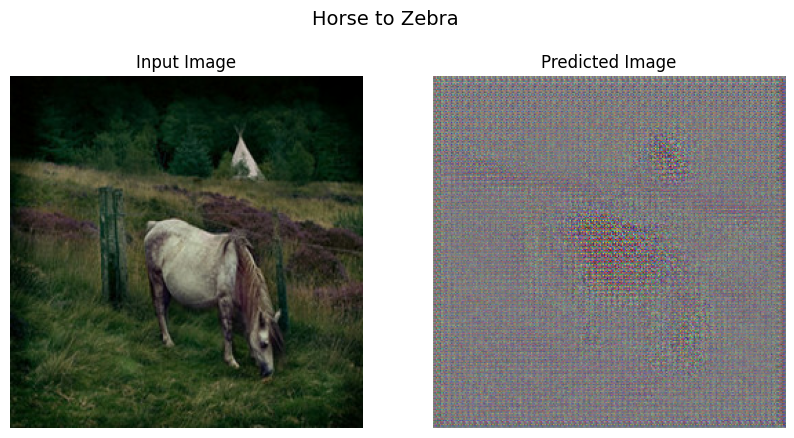

Sample zebra -> horse before training


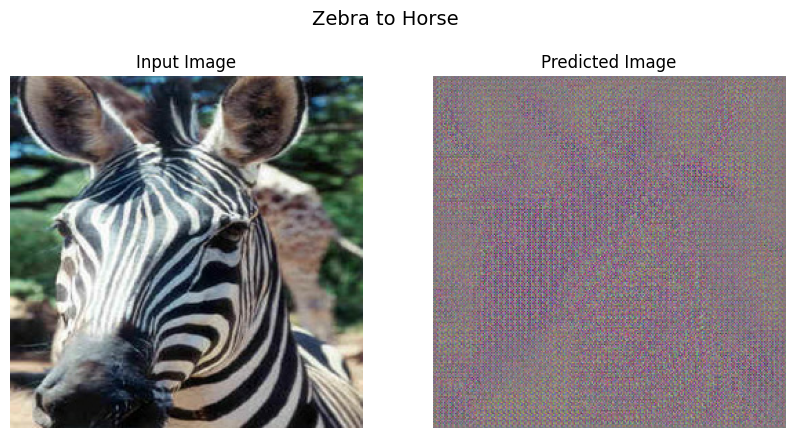


Epoch 1/20
step 0: G_loss=12.2948, F_loss=12.8682, Dx_loss=0.9310, Dy_loss=0.8729
step 100: G_loss=5.7446, F_loss=5.7641, Dx_loss=0.8202, Dy_loss=0.7953
step 200: G_loss=3.2770, F_loss=3.0440, Dx_loss=0.6990, Dy_loss=0.7768
step 300: G_loss=4.0087, F_loss=3.4324, Dx_loss=0.6669, Dy_loss=0.7435
step 400: G_loss=4.0253, F_loss=3.7212, Dx_loss=0.6998, Dy_loss=0.6902
step 500: G_loss=3.7343, F_loss=3.2716, Dx_loss=0.5178, Dy_loss=0.5607


In [ ]:
# ==========================================
# CYCLEGAN IN GOOGLE COLAB
# TensorFlow tutorial style
# horse <-> zebra
# ==========================================

# 1) Install dependencies
!pip -q install -U tensorflow tensorflow-datasets git+https://github.com/tensorflow/examples.git

# 2) Imports
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow_examples.models.pix2pix import pix2pix

import os
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

print("TensorFlow version:", tf.__version__)

AUTOTUNE = tf.data.AUTOTUNE

# ==========================================
# 3) LOAD DATASET
# ==========================================
dataset, metadata = tfds.load(
    "cycle_gan/horse2zebra",
    with_info=True,
    as_supervised=True
)

train_horses = dataset["trainA"]
train_zebras = dataset["trainB"]
test_horses = dataset["testA"]
test_zebras = dataset["testB"]

# ==========================================
# 4) HYPERPARAMETERS
# ==========================================
BUFFER_SIZE = 1000
BATCH_SIZE = 1
IMG_WIDTH = 256
IMG_HEIGHT = 256
LAMBDA = 10
EPOCHS = 20   # tutorial uses 40; you can increase later

# ==========================================
# 5) PREPROCESSING
# ==========================================
def random_crop(image):
    cropped_image = tf.image.random_crop(
        image, size=[IMG_HEIGHT, IMG_WIDTH, 3]
    )
    return cropped_image

def normalize(image):
    image = tf.cast(image, tf.float32)
    image = (image / 127.5) - 1
    return image

def random_jitter(image):
    # Resize to 286 x 286
    image = tf.image.resize(
        image, [286, 286],
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )

    # Random crop back to 256 x 256
    image = random_crop(image)

    # Random horizontal flip
    image = tf.image.random_flip_left_right(image)

    return image

def preprocess_image_train(image, label):
    image = random_jitter(image)
    image = normalize(image)
    return image

def preprocess_image_test(image, label):
    image = tf.image.resize(
        image, [IMG_HEIGHT, IMG_WIDTH],
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )
    image = normalize(image)
    return image

train_horses = (
    train_horses
    .map(preprocess_image_train, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

train_zebras = (
    train_zebras
    .map(preprocess_image_train, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

test_horses = (
    test_horses
    .map(preprocess_image_test, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
)

test_zebras = (
    test_zebras
    .map(preprocess_image_test, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
)

sample_horse = next(iter(test_horses))
sample_zebra = next(iter(test_zebras))

# ==========================================
# 6) BUILD MODELS
# ==========================================
OUTPUT_CHANNELS = 3

# Generators
generator_g = pix2pix.unet_generator(OUTPUT_CHANNELS, norm_type="instancenorm")  # horse -> zebra
generator_f = pix2pix.unet_generator(OUTPUT_CHANNELS, norm_type="instancenorm")  # zebra -> horse

# Discriminators
discriminator_x = pix2pix.discriminator(norm_type="instancenorm", target=False)   # for horses
discriminator_y = pix2pix.discriminator(norm_type="instancenorm", target=False)   # for zebras

# ==========================================
# 7) LOSSES
# ==========================================
loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real, generated):
    real_loss = loss_obj(tf.ones_like(real), real)
    generated_loss = loss_obj(tf.zeros_like(generated), generated)
    total_disc_loss = real_loss + generated_loss
    return total_disc_loss * 0.5

def generator_loss(generated):
    return loss_obj(tf.ones_like(generated), generated)

def calc_cycle_loss(real_image, cycled_image):
    loss = tf.reduce_mean(tf.abs(real_image - cycled_image))
    return LAMBDA * loss

def identity_loss(real_image, same_image):
    loss = tf.reduce_mean(tf.abs(real_image - same_image))
    return LAMBDA * 0.5 * loss

# ==========================================
# 8) OPTIMIZERS
# ==========================================
generator_g_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
generator_f_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

discriminator_x_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_y_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

# ==========================================
# 9) CHECKPOINTS
# ==========================================
checkpoint_path = "./checkpoints/train"

ckpt = tf.train.Checkpoint(
    generator_g=generator_g,
    generator_f=generator_f,
    discriminator_x=discriminator_x,
    discriminator_y=discriminator_y,
    generator_g_optimizer=generator_g_optimizer,
    generator_f_optimizer=generator_f_optimizer,
    discriminator_x_optimizer=discriminator_x_optimizer,
    discriminator_y_optimizer=discriminator_y_optimizer
)

ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

if ckpt_manager.latest_checkpoint:
    ckpt.restore(ckpt_manager.latest_checkpoint)
    print("Latest checkpoint restored!")

# ==========================================
# 10) VISUALIZATION
# ==========================================
def generate_images(model, test_input, title=""):
    prediction = model(test_input, training=False)

    plt.figure(figsize=(10, 5))

    display_list = [test_input[0], prediction[0]]
    titles = ["Input Image", "Predicted Image"]

    for i in range(2):
        plt.subplot(1, 2, i + 1)
        plt.title(titles[i])
        plt.imshow(display_list[i] * 0.5 + 0.5)
        plt.axis("off")

    if title:
        plt.suptitle(title, fontsize=14)

    plt.show()

print("Sample horse -> zebra before training")
generate_images(generator_g, sample_horse, title="Horse to Zebra")

print("Sample zebra -> horse before training")
generate_images(generator_f, sample_zebra, title="Zebra to Horse")

# ==========================================
# 11) TRAIN STEP
# ==========================================
@tf.function
def train_step(real_x, real_y):
    with tf.GradientTape(persistent=True) as tape:
        # G: X -> Y
        # F: Y -> X

        fake_y = generator_g(real_x, training=True)
        cycled_x = generator_f(fake_y, training=True)

        fake_x = generator_f(real_y, training=True)
        cycled_y = generator_g(fake_x, training=True)

        # identity mapping
        same_x = generator_f(real_x, training=True)
        same_y = generator_g(real_y, training=True)

        # discriminator outputs
        disc_real_x = discriminator_x(real_x, training=True)
        disc_real_y = discriminator_y(real_y, training=True)

        disc_fake_x = discriminator_x(fake_x, training=True)
        disc_fake_y = discriminator_y(fake_y, training=True)

        # generator adversarial losses
        gen_g_loss = generator_loss(disc_fake_y)
        gen_f_loss = generator_loss(disc_fake_x)

        # cycle consistency loss
        total_cycle_loss = calc_cycle_loss(real_x, cycled_x) + calc_cycle_loss(real_y, cycled_y)

        # total generator loss
        total_gen_g_loss = gen_g_loss + total_cycle_loss + identity_loss(real_y, same_y)
        total_gen_f_loss = gen_f_loss + total_cycle_loss + identity_loss(real_x, same_x)

        # discriminator loss
        disc_x_loss = discriminator_loss(disc_real_x, disc_fake_x)
        disc_y_loss = discriminator_loss(disc_real_y, disc_fake_y)

    # gradients
    generator_g_gradients = tape.gradient(total_gen_g_loss, generator_g.trainable_variables)
    generator_f_gradients = tape.gradient(total_gen_f_loss, generator_f.trainable_variables)

    discriminator_x_gradients = tape.gradient(disc_x_loss, discriminator_x.trainable_variables)
    discriminator_y_gradients = tape.gradient(disc_y_loss, discriminator_y.trainable_variables)

    # apply gradients
    generator_g_optimizer.apply_gradients(zip(generator_g_gradients, generator_g.trainable_variables))
    generator_f_optimizer.apply_gradients(zip(generator_f_gradients, generator_f.trainable_variables))

    discriminator_x_optimizer.apply_gradients(zip(discriminator_x_gradients, discriminator_x.trainable_variables))
    discriminator_y_optimizer.apply_gradients(zip(discriminator_y_gradients, discriminator_y.trainable_variables))

    return total_gen_g_loss, total_gen_f_loss, disc_x_loss, disc_y_loss

# ==========================================
# 12) TRAIN LOOP
# ==========================================
for epoch in range(EPOCHS):
    start = time.time()

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    n = 0

    for image_x, image_y in tf.data.Dataset.zip((train_horses, train_zebras)):
        g_loss, f_loss, dx_loss, dy_loss = train_step(image_x, image_y)

        if n % 100 == 0:
            print(
                f"step {n}: "
                f"G_loss={g_loss:.4f}, "
                f"F_loss={f_loss:.4f}, "
                f"Dx_loss={dx_loss:.4f}, "
                f"Dy_loss={dy_loss:.4f}"
            )
        n += 1

    clear_output(wait=True)

    print(f"Epoch {epoch + 1} finished")
    generate_images(generator_g, sample_horse, title=f"Epoch {epoch+1}: Horse to Zebra")
    generate_images(generator_f, sample_zebra, title=f"Epoch {epoch+1}: Zebra to Horse")

    if (epoch + 1) % 5 == 0:
        ckpt_save_path = ckpt_manager.save()
        print(f"Saving checkpoint for epoch {epoch+1} at {ckpt_save_path}")

    print(f"Time taken for epoch {epoch + 1}: {time.time() - start:.2f} sec")

# ==========================================
# 13) TEST RESULTS
# ==========================================
print("Final test examples:")
for inp in test_horses.take(3):
    generate_images(generator_g, inp, title="Horse to Zebra")

for inp in test_zebras.take(3):
    generate_images(generator_f, inp, title="Zebra to Horse")

# ==========================================
# 14) SAVE MODELS
# ==========================================
generator_g.save("cyclegan_generator_g_horse2zebra.keras")
generator_f.save("cyclegan_generator_f_zebra2horse.keras")

print("Models saved successfully.")